# ***Laboratório 4.A - Filtragem de Imagens (Filtros Passa-baixa)***

## **Integrantes**
- Matheus Foresto Moselli
- Marcos Vinicius Medeiros da Silva
- Karl Eloy Marques Henrique

**Data do experimento:** 10/03/2026 <br/>
**Data de publicação do relatório:** 13/03/2026

## **Introdução**

Nesse laboratório iremos estudar os filtros **passa-baixa.** <br />
Esse tipo de filtro é utilizado para suavizar transições brutas de intensidades em imagens resultando em um efeito de *blur* (borrão).

Os filtros passa-baixa atuam reduzindo as **altas frequências espaciais** da imagem, que geralmente estão associadas a ruídos, detalhes muito finos e mudanças abruptas entre pixels vizinhos. Ao preservar principalmente as **baixas frequências**, esses filtros mantêm as estruturas mais suaves e gerais da imagem.

Filtros passa-baixa são muito utilizados para tarefas como **redução de ruído**, suavização de texturas e preparação da imagem para outras etapas de processamento, como detecção de bordas ou segmentação.

## **Procedimentos Experimentais**

*1) Nesta etapa, utilize suas próprias imagens obtidas no Lab3 - imagem dos membros juntos do grupo e imagem dos avatar juntos.*

*(a) Elabore um programa que realize as filtragens (com os filtros de média, gaussiano, mediana, e bilateral) na sua imagem com um kernel 3x3, 5x5, 11x11, e 29x29 e salve as imagens resultantes de cada filtragem, em formato .jpg.*

### **Filtro de média**

Esse filtro consiste em substituir o valor de intensidade de cada pixel pela media aritmética dos valores dos pixels na sua vizinhança. O tamanho da vizinhança é definido pelo kernel.

Nesse exemplos, aplicamos o filtro utilizando vizinhanças com 4 tamanhos diferentes:
- 3x3 (px)
- 5x5 (px)
- 11x11 (px)
- 29x29 (px)

Esse tipo de filtro é muito utilizado para reduzir ruídos na imagem. Como consequência do processo de suavização, ocorre também uma redução dos detalhes e um borramento das bordas.

A fórmula para aplicação desse filtro é a seguinte: <br />

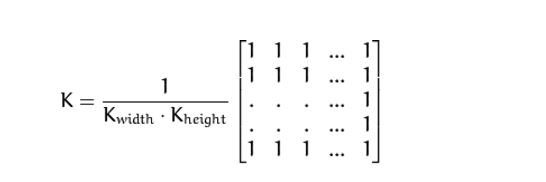


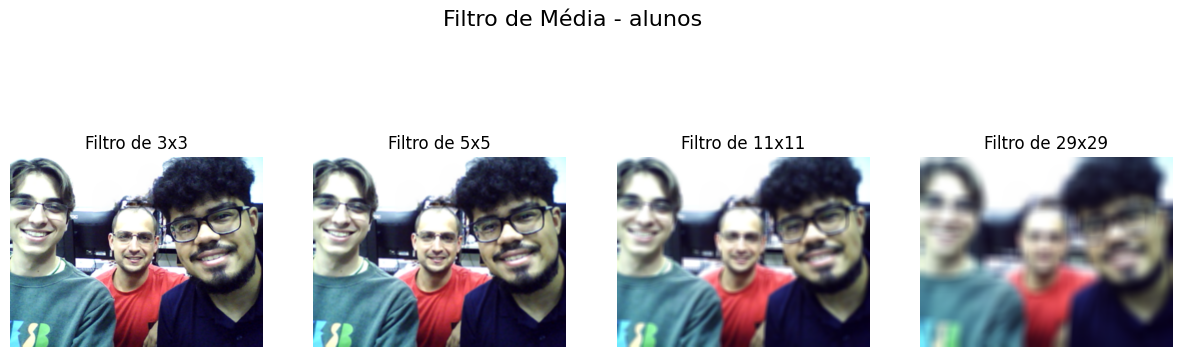

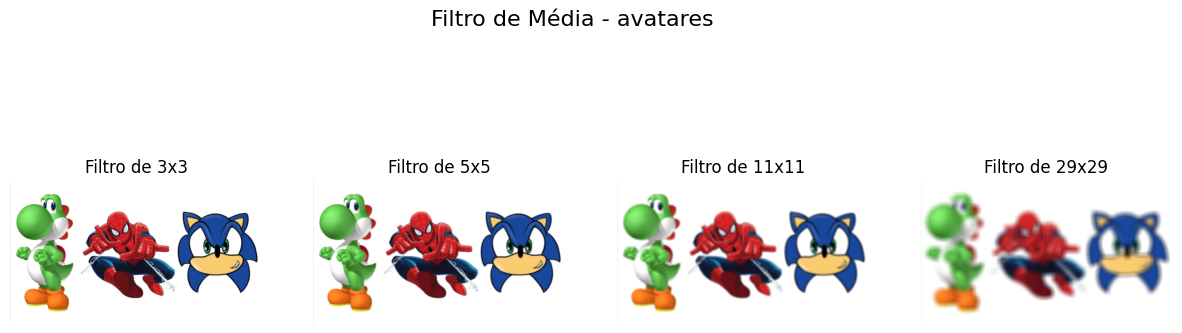

In [20]:
# Filtro de média - Homogeneous Blur
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

#  Global Variables

KERNELS = [3, 5, 11, 29]
arquivos = ["alunos", "avatares"]
src = "img"
dst = "filtros"

def homogeneous_blur(src_img, dst_img, title):
    for i in range(0, len(KERNELS)):
        kernel_size = KERNELS[i]
        dst_img = cv.blur(src_img, (kernel_size, kernel_size))

        dst_file_name = f"{dst}/media/{title}/{kernel_size}x{kernel_size}.jpg"
        cv.imwrite(dst_file_name, cv.cvtColor(dst_img, cv.COLOR_BGR2RGB))

        plt.subplot(1,len(KERNELS),i+1)
        plt.imshow(dst_img)
        plt.title(f'Filtro de {kernel_size}x{kernel_size}')
        plt.axis('off')

for file in arquivos:
    # Load the source image
    image_name = f'{src}/{file}.png'

    cv_src_file = cv.imread(image_name)
    cv_src_file = cv.cvtColor(cv_src_file, cv.COLOR_BGR2RGB)
    
    cv_dst_file = np.copy(cv_src_file)

    plt.figure(figsize=(15,5))
    
    plt.suptitle(f"Filtro de Média - {file}", fontsize=16)
    
    homogeneous_blur(cv_src_file, cv_dst_file, file)
    
    plt.show()

### **Filtro gaussiano**

Esse filtro consiste em substituir o valor de intensidade de cada pixel por uma média ponderada dos valores dos pixels na sua vizinhança. Diferente do filtro de média simples, os pixels mais próximos do centro recebem maior peso, enquanto os mais distantes recebem pesos menores, seguindo uma distribuição gaussiana. O tamanho da vizinhança é definido pelo kernel.

Nesse exemplo, aplicamos o filtro utilizando vizinhanças com 4 tamanhos diferentes:

- 3x3 (px)
- 5x5 (px)
- 11x11 (px)
- 29x29 (px)

Esse tipo de filtro é muito utilizado para reduzir ruídos e realizar suavização da imagem, preservando melhor as estruturas importantes quando comparado ao filtro de média. Como consequência, ocorre uma redução de detalhes finos e suavização das bordas.

A fórmula para aplicação desse filtro é a seguinte: <br />

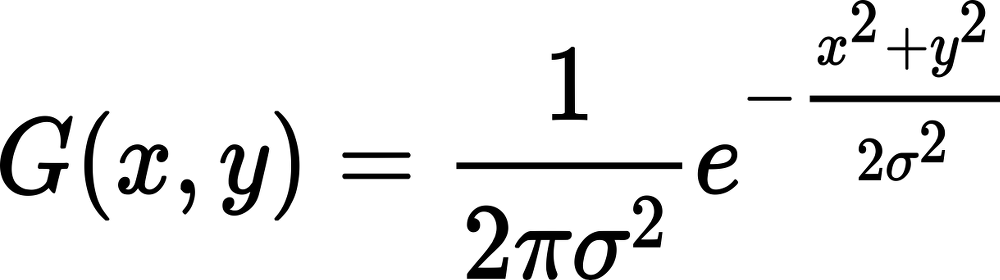

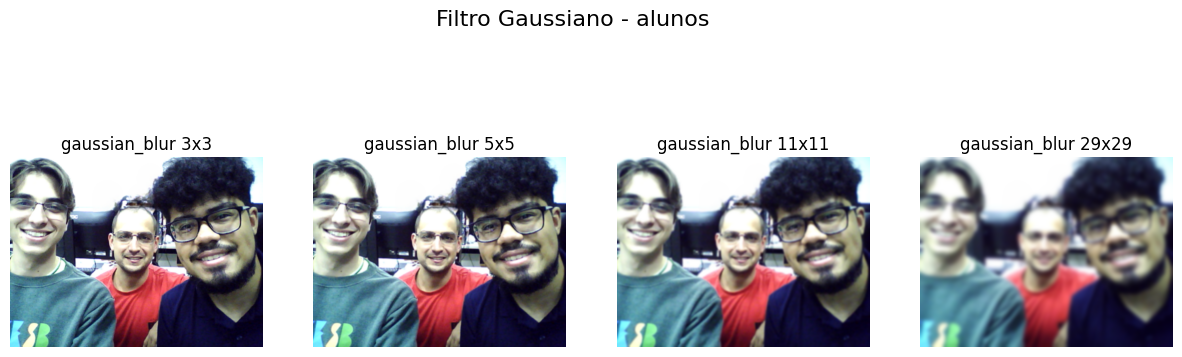

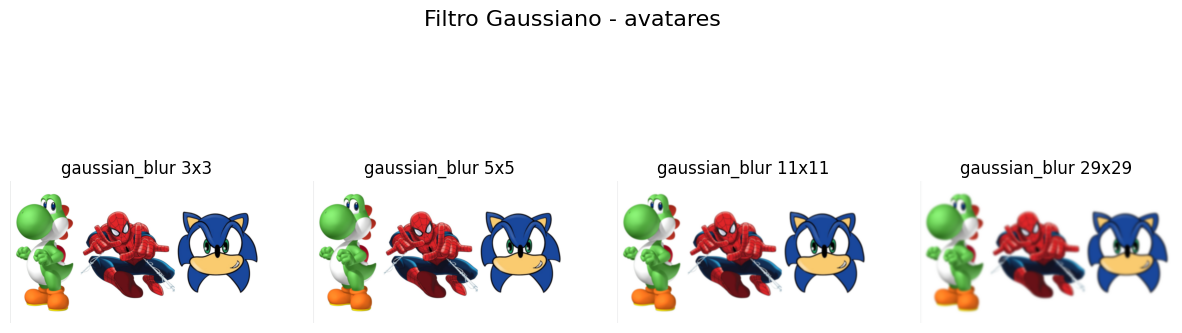

In [21]:
# Filtro gaussiano - Gaussian Blur
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

#  Global Variables

KERNELS = [3, 5, 11, 29]
arquivos = ["alunos", "avatares"]
src = "img"
dst = "filtros"

def gaussian_blur(src_img, dst_img, title):
    for i in range(0, len(KERNELS)):
        kernel_size = KERNELS[i]
        dst_img = cv.GaussianBlur(src_img, (kernel_size, kernel_size), 0)

        dst_file_name = f"{dst}/gaussiana/{title}/{kernel_size}x{kernel_size}.jpg"
        cv.imwrite(dst_file_name, cv.cvtColor(dst_img, cv.COLOR_BGR2RGB))

        plt.subplot(1,len(KERNELS),i+1)
        plt.imshow(dst_img)
        plt.title(f'gaussian_blur {kernel_size}x{kernel_size}')
        plt.axis('off')

for file in arquivos:
    # Load the source image
    image_name = f'{src}/{file}.png'

    cv_src_file = cv.imread(image_name)
    cv_src_file = cv.cvtColor(cv_src_file, cv.COLOR_BGR2RGB)
    
    cv_dst_file = np.copy(cv_src_file)

    plt.figure(figsize=(15,5))
    
    plt.suptitle(f"Filtro Gaussiano - {file}", fontsize=16)
    
    gaussian_blur(cv_src_file, cv_dst_file, file)
    
    plt.show()

### **Filtro da mediana**

Esse filtro consiste em substituir o valor de intensidade de cada pixel pelo valor da mediana dos pixels presentes na sua vizinhança. Para isso, todos os valores de intensidade dentro do kernel são ordenados e o valor central dessa ordenação é utilizado como novo valor para o pixel analisado. O tamanho da vizinhança é definido pelo kernel.

Nesse exemplo, aplicamos o filtro utilizando vizinhanças com 4 tamanhos diferentes:

- 3x3 (px)
- 5x5 (px)
- 11x11 (px)
- 29x29 (px)

Esse tipo de filtro é muito utilizado para reduzir ruídos do tipo sal-e-pimenta, pois valores extremos (muito altos ou muito baixos) têm pouca influência no resultado da mediana. Como consequência, o filtro consegue remover ruídos preservando melhor as bordas da imagem quando comparado a filtros baseados em média.

Um exemplo da aplicação desse filtro: <br />

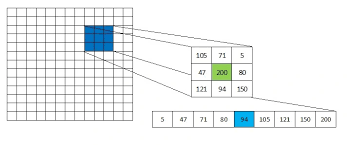

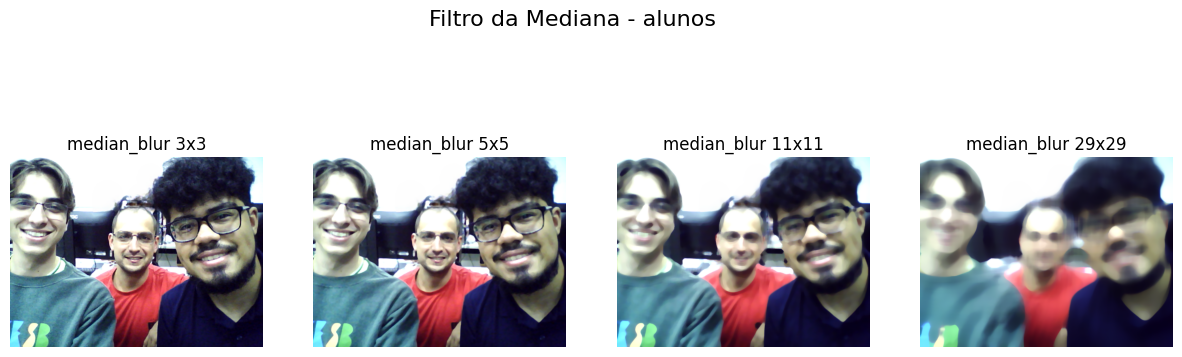

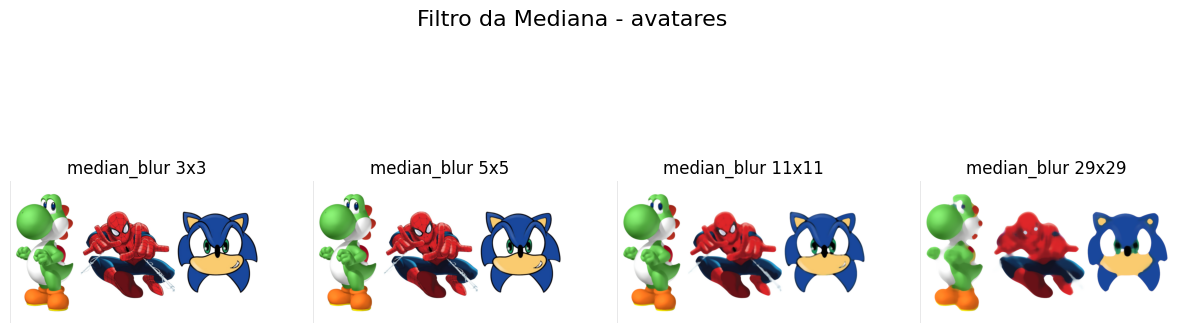

In [22]:
# Filtro de mediana - Median Blur
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

#  Global Variables

KERNELS = [3, 5, 11, 29]
arquivos = ["alunos", "avatares"]
src = "img"
dst = "filtros"

def median_blur(src_img, dst_img, title):
    for i in range(0, len(KERNELS)):
        kernel_size = KERNELS[i]
        dst_img = cv.medianBlur(src_img, kernel_size)

        dst_file_name = f"{dst}/mediana/{title}/{kernel_size}x{kernel_size}.jpg"
        cv.imwrite(dst_file_name, cv.cvtColor(dst_img, cv.COLOR_BGR2RGB))

        plt.subplot(1,len(KERNELS),i+1)
        plt.imshow(dst_img)
        plt.title(f'median_blur {kernel_size}x{kernel_size}')
        plt.axis('off')

for file in arquivos:
    # Load the source image
    image_name = f'{src}/{file}.png'

    cv_src_file = cv.imread(image_name)
    cv_src_file = cv.cvtColor(cv_src_file, cv.COLOR_BGR2RGB)
    
    cv_dst_file = np.copy(cv_src_file)

    plt.figure(figsize=(15,5))
    
    plt.suptitle(f"Filtro da Mediana - {file}", fontsize=16)
    
    median_blur(cv_src_file, cv_dst_file, file)
    
    plt.show()

### **Filtro bilateral**

Esse filtro consiste em substituir o valor de intensidade de cada pixel por uma média ponderada dos valores dos pixels na sua vizinhança, levando em consideração dois fatores: a distância espacial entre os pixels e a diferença de intensidade entre eles. Pixels próximos e com valores de intensidade semelhantes recebem pesos maiores, enquanto pixels distantes ou muito diferentes em intensidade recebem pesos menores. O tamanho da vizinhança é definido pelo kernel.

Nesse exemplo, aplicamos o filtro utilizando vizinhanças com 4 tamanhos diferentes:

- 3x3 (px)
- 5x5 (px)
- 11x11 (px)
- 29x29 (px)

Esse tipo de filtro é muito utilizado para realizar suavização da imagem enquanto preserva as bordas, pois a diferença de intensidade entre pixels faz com que regiões com mudanças bruscas (bordas) tenham menor influência no cálculo da média. Como consequência, o filtro reduz ruídos sem borrar significativamente as bordas da imagem.

A fórmula para aplicação desse filtro é a seguinte: <br />

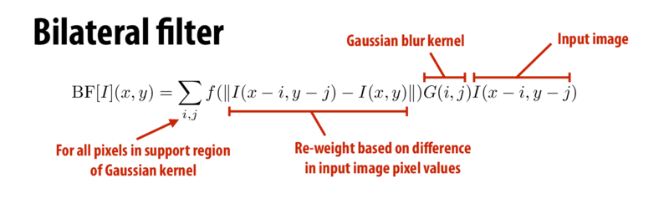

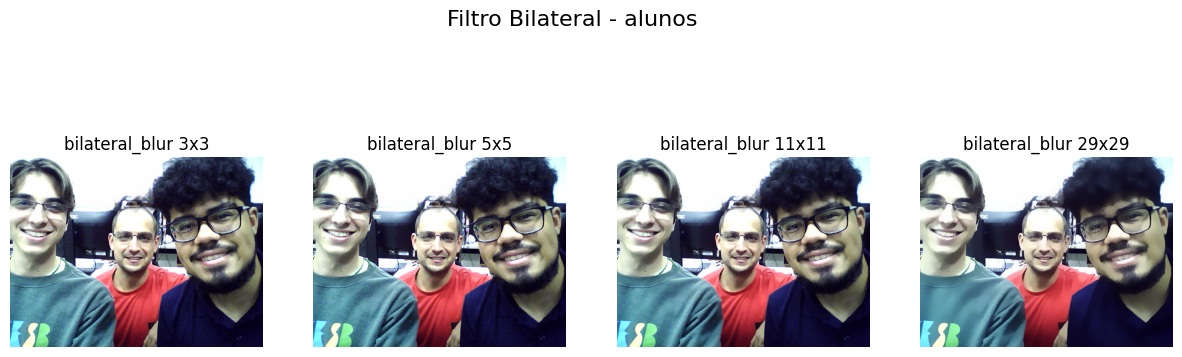

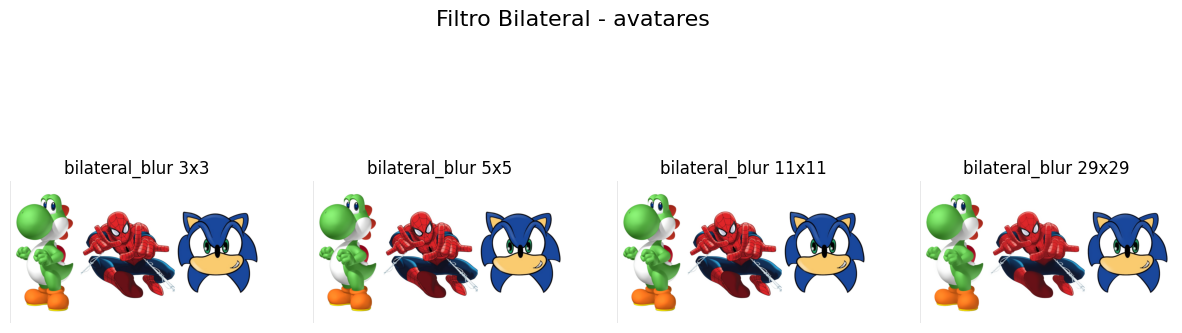

In [23]:
# Filtro bilateral - Bilateral Blur
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

#  Global Variables

KERNELS = [3, 5, 11, 29]
arquivos = ["alunos", "avatares"]
src = "img"
dst = "filtros"

def bilateral_blur(src_img, dst_img, title):
    for i in range(0, len(KERNELS)):
        kernel_size = KERNELS[i]
        dst_img = cv.bilateralFilter(src_img, kernel_size, kernel_size * 2, kernel_size / 2)

        dst_file_name = f"{dst}/bilateral/{title}/{kernel_size}x{kernel_size}.jpg"
        cv.imwrite(dst_file_name, cv.cvtColor(dst_img, cv.COLOR_BGR2RGB))

        plt.subplot(1,len(KERNELS),i+1)
        plt.imshow(dst_img)
        plt.title(f'bilateral_blur {kernel_size}x{kernel_size}')
        plt.axis('off')

for file in arquivos:
    # Load the source image
    image_name = f'{src}/{file}.png'

    cv_src_file = cv.imread(image_name)
    cv_src_file = cv.cvtColor(cv_src_file, cv.COLOR_BGR2RGB)
    
    cv_dst_file = np.copy(cv_src_file)

    
    plt.figure(figsize=(15,5))
    
    plt.suptitle(f"Filtro Bilateral - {file}", fontsize=16)
    
    bilateral_blur(cv_src_file, cv_dst_file, file)
    
    plt.show()

*(b) Aplicação dos filtros nas imagens com ruído*

Após a geração das imagens contendo ruído gaussiano e ruído sal-e-pimenta, aplicamos os filtros passa-baixa estudados anteriormente com o objetivo de reduzir as distorções presentes nas imagens.

Foram utilizados os seguintes filtros:

- filtro de **média**
- filtro **gaussiano**
- filtro da **mediana**
- filtro **bilateral**

Cada filtro foi aplicado às imagens ruidosas utilizando diferentes tamanhos de **kernel**, permitindo observar como o tamanho da vizinhança influencia no resultado da filtragem:

- 3×3 (px)  
- 5×5 (px)  
- 11×11 (px)  
- 29×29 (px)

O processamento foi realizado utilizando a biblioteca **OpenCV** em Python. Para cada combinação de filtro, tamanho de kernel e tipo de ruído, a imagem resultante é exibida e também salva automaticamente em diretórios organizados por tipo de filtro, facilitando a comparação posterior dos resultados.

---

*(c) Análise dos resultados utilizando PSNR*

A análise quantitativa via *PSNR (Peak Signal-to-Noise Ratio)*, aliada à inspeção qualitativa das imagens processadas, permite traçar conclusões fundamentais sobre a resposta em frequência dos filtros aplicados e sua eficácia frente a diferentes modelos de ruído.

**Comportamento dos Filtros frente aos Modelos de Ruído**

1.  **Ruído Gaussiano:**
    A natureza estatística do ruído gaussiano, que se distribui de forma homogênea pelo espectro, favorece a aplicação de filtros lineares de suavização. Os filtros de **Média** e **Gaussiano** apresentaram os melhores desempenhos objetivos, com o filtro Gaussiano de $K=11$ atingindo um pico de **20.1 dB**. Isso ocorre porque o kernel gaussiano pondera mais os pixels centrais, reduzindo a variância do ruído sem degradar tão agressivamente a estrutura da imagem quanto a média aritmética simples.

2.  **Ruído Sal e Pimenta:**
    Neste cenário, observou-se uma discrepância acentuada entre os filtros. Enquanto os filtros de Média e Bilateral falharam em isolar os impulsos (chegando a "espalhar" o erro para a vizinhança), o **Filtro de Mediana** demonstrou superioridade absoluta. Ao operar como um filtro de ordem, ele ignora os valores extremos (outliers) típicos deste ruído. O PSNR de **28.9 dB** obtido na imagem "Avatares" com $K=5$ evidencia que a mediana consegue restaurar a imagem original quase integralmente, mantendo a integridade dos objetos.

**A dimensão do Kernel ($K$)**

A variação do parâmetro $K$ revelou a importância do ajuste fino em processamento digital de imagens. Notou-se que:
* **Kernels Reduzidos ($K=3$ ou $5$):** São ideais para manter a acuidade visual e as altas frequências (bordas), porém podem ser insuficientes para suprimir ruídos de alta amplitude.
* **Kernels Elevados ($K=29$):** Independentemente da técnica, kernels muito amplos agem como filtros passa-baixa severos. O borramento excessivo introduz um erro quadrático médio tão alto que o PSNR declina drasticamente, tornando a imagem "inteligível" mas tecnicamente pobre em detalhes semânticos.

**Considerações sobre a Filtragem Passa-Baixa**

A filtragem passa-baixa é uma ferramenta de pré-processamento poderosa, mas não universal. Do ponto de vista técnico:
* **Adequação:** O filtro **Bilateral** mostrou-se a alternativa mais equilibrada para preservação de contornos, embora suas métricas de PSNR sejam frequentemente punidas por não suavizarem o ruído de forma tão homogênea quanto o filtro Gaussiano.
* **Utilidade:** Em sistemas de visão computacional reais, a escolha do filtro deve preceder a análise do sensor. Para ruído térmico, a suavização gaussiana é mandatória; para erros de transmissão, a mediana é indispensável. 

Em suma, a métrica PSNR serve como um excelente balizador inicial, mas a decisão técnica final deve considerar o objetivo da aplicação.

*2) Elabore um novo programa em que a imagem de entrada é da webcam, e que mostre o resultado da filtragem numa janela opencv, de forma contínua na tela do computador. Utilize a tecla [s] do teclado para permitir salvar a imagem sendo apresentada na tela, em formato .jpg. Neste caso, escolha apenas  dois tipos de filtragem e tamanho de kernel, baseado no melhor e no pior resultado obtidos na parte (2) acima.*

Nessa seção, vamos montar um código que aplica os filtros **bilateral** (melhor) e da **mediana** (pior) diretamente na imagem da *webcam*. Além disso, iremos utilizar os kernels **3x3** e **29x29**, o menor e o maior do último exercício, respectivamente.

Vamos iniciar pelo filtro da **mediana**, utilizando um kernel de **3x3**:

In [24]:
# Filtro de mediana aplicado diretamente na câmera (3x3)
import cv2 as cv
from datetime import datetime


TAMANHO_KERNEL = 3

cap = cv.VideoCapture(0)

width = cap.get(cv.CAP_PROP_FRAME_WIDTH)
height = cap.get(cv.CAP_PROP_FRAME_HEIGHT)

fps = 60.0 # alterar pra um valor alto pra capturar os videos rápidos

while cap.isOpened():
    ret, frame = cap.read()

    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break

    frame_filtrado = cv.medianBlur(frame, TAMANHO_KERNEL)

    cv.imshow('frame', frame_filtrado)
    tecla_pressionada = cv.waitKey(1)

    if tecla_pressionada == ord('q'):
        break

    if tecla_pressionada == ord('s'):
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        nome_arquivo = f"exe2_gravacao/foto_{timestamp}.jpg"
        cv.imwrite(f"filtros/exe2_gravacao/3x3_mediana_{timestamp}.jpg", frame_filtrado)


cap.release()
cv.destroyAllWindows()

Podemos observar que o filtro surtiu pouco efeito no resultado final.

Agora vamos observar o mesmo filtro utilizando um kernel de **29x29**

In [25]:
# Filtro de mediana aplicado diretamente na câmera (29x29)
import cv2 as cv
from datetime import datetime


TAMANHO_KERNEL = 29

cap = cv.VideoCapture(0)

width = cap.get(cv.CAP_PROP_FRAME_WIDTH)
height = cap.get(cv.CAP_PROP_FRAME_HEIGHT)

fps = 60.0 # alterar pra um valor alto pra capturar os videos rápidos

while cap.isOpened():
    ret, frame = cap.read()

    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break

    frame_filtrado = cv.medianBlur(frame, TAMANHO_KERNEL)

    cv.imshow('frame', frame_filtrado)
    tecla_pressionada = cv.waitKey(1)

    if tecla_pressionada == ord('q'):
        break

    if tecla_pressionada == ord('s'):
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        nome_arquivo = f"exe2_gravacao/foto_{timestamp}.jpg"
        cv.imwrite(f"filtros/exe2_gravacao/29x29_mediana_{timestamp}.jpg", frame_filtrado)


cap.release()
cv.destroyAllWindows()

Utilizando um kernel notavelmente maior, foi possível perceber o efeito do filtro sobre a imagem da webcam. Além disso, observamos que o kernel de 29x29 é desnecessariamente grande, gerando mais "prejuízos" para a imagem do que ajudando.

Agora vamos observar o filtro **bilateral** utilizando um kernel de **3x3**

In [26]:
# Filtro bilateral aplicado diretamente na câmera (3x3)
import cv2 as cv
from datetime import datetime


TAMANHO_KERNEL = 3

cap = cv.VideoCapture(0)

width = cap.get(cv.CAP_PROP_FRAME_WIDTH)
height = cap.get(cv.CAP_PROP_FRAME_HEIGHT)

fps = 60.0 # alterar pra um valor alto pra capturar os videos rápidos

while cap.isOpened():
    ret, frame = cap.read()

    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break

    frame_filtrado = cv.bilateralFilter(frame, TAMANHO_KERNEL, TAMANHO_KERNEL * 2, TAMANHO_KERNEL / 2)

    cv.imshow('frame', frame_filtrado)
    tecla_pressionada = cv.waitKey(1)

    if tecla_pressionada == ord('q'):
        break

    if tecla_pressionada == ord('s'):
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        nome_arquivo = f"exe2_gravacao/foto_{timestamp}.jpg"
        cv.imwrite(f"filtros/exe2_gravacao/3x3_bilateral_{timestamp}.jpg", frame_filtrado)


cap.release()
cv.destroyAllWindows()

Assim como o filtro de mediana, notamos que o kernel 3x3 não é o suficiente para perceber mudanças na imagem final.
Portanto, vamos aplicar o kernel de **29x29** nesse filtro:

In [27]:
# Filtro bilateral aplicado diretamente na câmera (29x29)
import cv2 as cv
from datetime import datetime


TAMANHO_KERNEL = 29

cap = cv.VideoCapture(0)

width = cap.get(cv.CAP_PROP_FRAME_WIDTH)
height = cap.get(cv.CAP_PROP_FRAME_HEIGHT)

fps = 60.0 # alterar pra um valor alto pra capturar os videos rápidos

while cap.isOpened():
    ret, frame = cap.read()

    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break

    frame_filtrado = cv.bilateralFilter(frame, TAMANHO_KERNEL, TAMANHO_KERNEL * 2, TAMANHO_KERNEL / 2)

    cv.imshow('frame', frame_filtrado)
    tecla_pressionada = cv.waitKey(1)

    if tecla_pressionada == ord('q'):
        break

    if tecla_pressionada == ord('s'):
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        nome_arquivo = f"exe2_gravacao/foto_{timestamp}.jpg"
        cv.imwrite(f"filtros/exe2_gravacao/3x3_bilateral_{timestamp}.jpg", frame_filtrado)


cap.release()
cv.destroyAllWindows()

Utilizando o kernel de 29x29 foi possível notar a diferença aplicada pelo filtro bilateral. Entretanto, diferente do filtro de mediana, a imagem final ainda pode ser considerada de qualidade, sendo possível distinguir os objetos e as pessoas na imagem.

*3) Desafio (opcional): elabore um programa de filtragem para entrada webcam, e que mostre o resultado da filtragem numa janela opencv, sendo que permitirá ao usuário escolher o tipo de filtragem, o tamanho do kernel, e o tipo de ruído inserido.*
- *Através das teclas [a], [g], [m], e [b] do teclado, para os filtros de média, gaussiano, mediana, e bilateral, respectivamente.*
- *Através das teclas [3], [5], [7], [9], [x] do teclado, para os kernel (3x3), (5x5), (11x11), (29x29), e (47x47) respectivamente.*
- *Através das teclas [o], [y], [p] do teclado, para "sem ruído", "ruido gaussiano", "ruído sal-e-pimenta" respectivamente.*

In [29]:
# Filtro em tempo real (desafio)
import cv2 as cv
cap = cv.VideoCapture(0)

width = cap.get(cv.CAP_PROP_FRAME_WIDTH)
height = cap.get(cv.CAP_PROP_FRAME_HEIGHT)

fps = 60.0 # alterar pra um valor alto pra capturar os videos rápidos

filtro_aplicado = None
kernel_aplicado = 1
ruido_aplicado = None

def validar_filtro_selecionado(tecla_pressionada):
    if tecla_pressionada == ord('a'):
        return "media"
    elif tecla_pressionada == ord('g'):
        return "gaussiano"
    elif tecla_pressionada == ord('m'):
        return "mediana"
    elif tecla_pressionada == ord('b'):
        return "bilateral"

    return None

def validar_kernel_selecionado(tecla_pressionada):
    # Kernels
    if tecla_pressionada == ord('3'):
        return 3
    elif tecla_pressionada == ord('5'):
        return 5
    elif tecla_pressionada == ord('7'):
        return 11
    elif tecla_pressionada == ord('9'):
        return 29
    elif tecla_pressionada == ord('x'):
        return 47

    return None

def validar_ruido_selecionado(tecla_pressionada):
    if tecla_pressionada == ord('o'):
        return None
    elif tecla_pressionada == ord('y'):
        return "gaussiano"
    elif tecla_pressionada == ord('p'):
        return "sal-pimenta"

    return None

while cap.isOpened():
    ret, frame = cap.read()

    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break

    frame_filtrado = frame

    if filtro_aplicado == "media":
        frame_filtrado = cv.blur(frame, (kernel_aplicado, kernel_aplicado))
    elif filtro_aplicado == "gaussiano":
        frame_filtrado = cv.GaussianBlur(frame, (kernel_aplicado, kernel_aplicado), 0)
    elif filtro_aplicado == "mediana":
        frame_filtrado = cv.medianBlur(frame, kernel_aplicado)
    elif filtro_aplicado == "bilateral":
        frame_filtrado = cv.bilateralFilter(frame, kernel_aplicado, kernel_aplicado * 2, kernel_aplicado / 2)

    cv.imshow('frame', frame_filtrado)
    tecla = cv.waitKey(1)

    if tecla == ord('q'):
        break
    elif tecla != -1:
        novo_filtro_aplicado = validar_filtro_selecionado(tecla)
        if novo_filtro_aplicado is not None:
            filtro_aplicado = novo_filtro_aplicado

        novo_kernel_aplicado = validar_kernel_selecionado(tecla)
        if novo_kernel_aplicado is not None:
            kernel_aplicado = novo_kernel_aplicado

        novo_ruido_aplicado = validar_ruido_selecionado(tecla)
        if novo_ruido_aplicado is not None:
            ruido_aplicado = novo_ruido_aplicado


cap.release()
cv.destroyAllWindows()

## **Conclusões**

## **Referências**

- MINICHINO, J.; HOWSE, J. **Learning OpenCV 3 Computer Vision with Python. 2**. ed. [S.l.]: Packt Publishing, 2015.
- OPENCV. **Flags used for image file reading and writing**. Versão 3.4.20-dev. Disponível em: https://docs.opencv.org/3.4/d8/d6a/group__imgcodecs__flags.html. Acesso em: 20 fev. 2026.
- OPENCV. **Getting Started with Images**. Disponível em: https://docs.opencv.org/4.x/db/deb/tutorial_display_image.html. Acesso em: 21 fev. 2026.
- OPENCV. **Getting Started with Videos**. Disponível em: https://docs.opencv.org/4.x/dd/d43/tutorial_py_video_display.html. Acesso em: 21 fev. 2026.
- OPENCV. **OpenCV-Python Tutorials**. Disponível em: https://docs.opencv.org/master/d6/d00/tutorial_py_root.html. Acesso em: 20 fev. 2026.
- OPENCV. **Smoothing Images**. Disponível em: https://docs.opencv.org/4.x/dc/dd3/tutorial_gausian_median_blur_bilateral_filter.html. Acesso em: 10 mar. 2026.